In [1]:
# ---Imports------------------------------------------------------------------

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier


# ---Notebook configuration---------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")


# ---Project paths------------------------------------------------------------

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

DEV_DATA_PATH = PROCESSED_DATA_DIR / "dev_modeling_dataset.parquet"


# ---Sanity check-------------------------------------------------------------

print("Project root:", PROJECT_ROOT.resolve())
print("Development dataset path:", DEV_DATA_PATH.resolve())
print("File exists:", DEV_DATA_PATH.exists())

Project root: C:\Users\zeina
Development dataset path: C:\Users\zeina\data\processed\dev_modeling_dataset.parquet
File exists: True


# Define Features and Target

In [3]:
# ---Load dataset-------------------------------------------------------------

df = pd.read_parquet(DEV_DATA_PATH)

print("Dataset loaded successfully.")
print()
print("Dataset shape:", df.shape)
print()
print("Target distribution:")
print(df["isFraud"].value_counts(normalize=True))

# ---Target variable----------------------------------------------------------
target_col = "isFraud"

y = df[target_col]
X = df.drop(columns=[target_col])

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Number of features:", X.shape[1])

Dataset loaded successfully.

Dataset shape: (472432, 464)

Target distribution:
isFraud
0   0.9649
1   0.0351
Name: proportion, dtype: float64
Feature matrix shape: (472432, 463)
Target vector shape: (472432,)
Number of features: 463


# Time-Aware Train / Validation Split

In [4]:
# ---Create time-aware split--------------------------------------------------
n_rows = len(X)
split_index = int(n_rows * 0.8)

X_train = X.iloc[:split_index].copy()
X_valid = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_valid = y.iloc[split_index:].copy()


# ---Sanity check-------------------------------------------------------------
print("Train shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print()

print("Fraud rate (train):", y_train.mean())
print("Fraud rate (valid):", y_valid.mean())

# ---Detect feature types-----------------------------------------------------
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Train shape: (377945, 463)
Validation shape: (94487, 463)

Fraud rate (train): 0.03411872097792007
Fraud rate (valid): 0.039201159947929345
Numeric features: 428
Categorical features: 35


# Build Preprocessing Pipelines

In [5]:
# ---Numeric preprocessing----------------------------------------------------
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)


# ---Categorical preprocessing------------------------------------------------
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


# ---Column transformer-------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

# ---Reusable evaluation function---------------------------------------------
def evaluate_model(model_name, fitted_model, X_valid, y_valid, threshold=0.5):
    y_pred_proba = fitted_model.predict_proba(X_valid)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)

    roc_auc = roc_auc_score(y_valid, y_pred_proba)
    pr_auc = average_precision_score(y_valid, y_pred_proba)
    precision = precision_score(y_valid, y_pred, zero_division=0)
    recall = recall_score(y_valid, y_pred, zero_division=0)
    f1 = f1_score(y_valid, y_pred, zero_division=0)

    metrics = pd.DataFrame({
        "model": [model_name],
        "roc_auc": [roc_auc],
        "pr_auc": [pr_auc],
        "precision": [precision],
        "recall": [recall],
        "f1": [f1],
    })

    return metrics, y_pred_proba, y_pred

# Random Forest Model

Random Forest training complete.


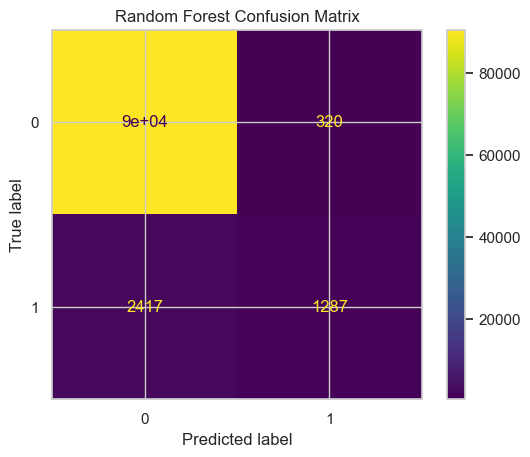

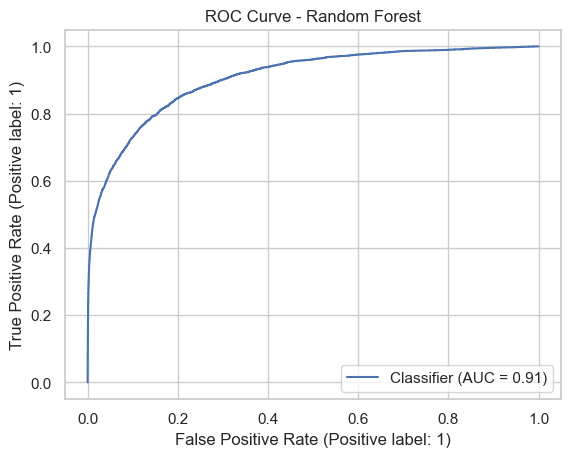

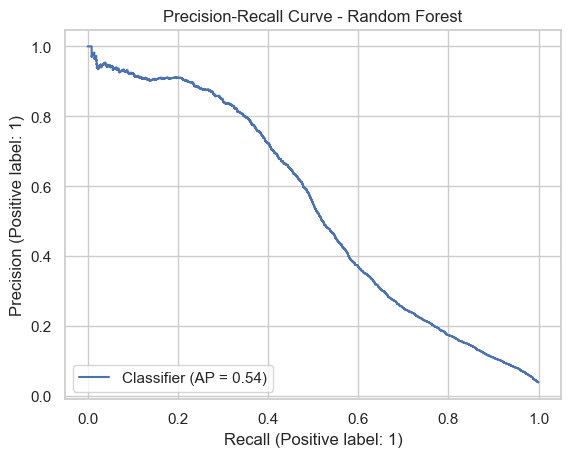

In [6]:
# ---Define model-------------------------------------------------------------
rf_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
)


# ---Full modeling pipeline---------------------------------------------------
rf_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", rf_classifier),
    ]
)


# ---Train model--------------------------------------------------------------
rf_model.fit(X_train, y_train)

print("Random Forest training complete.")

# ---Validation metrics-------------------------------------------------------
rf_results, rf_pred_proba, rf_pred = evaluate_model(
    model_name="Random Forest",
    fitted_model=rf_model,
    X_valid=X_valid,
    y_valid=y_valid,
)

rf_results

# ---Confusion matrix---------------------------------------------------------
rf_cm = confusion_matrix(y_valid, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()


# ---ROC curve----------------------------------------------------------------
RocCurveDisplay.from_predictions(y_valid, rf_pred_proba)

plt.title("ROC Curve - Random Forest")
plt.show()


# ---Precision-Recall curve---------------------------------------------------
PrecisionRecallDisplay.from_predictions(y_valid, rf_pred_proba)

plt.title("Precision-Recall Curve - Random Forest")
plt.show()

# XGBoost Model

scale_pos_weight: 28.3094
XGBoost training complete.


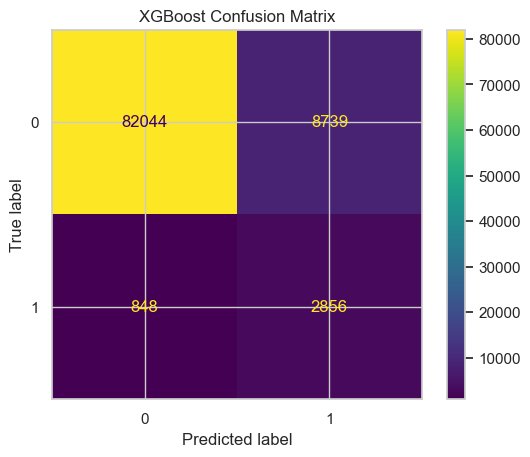

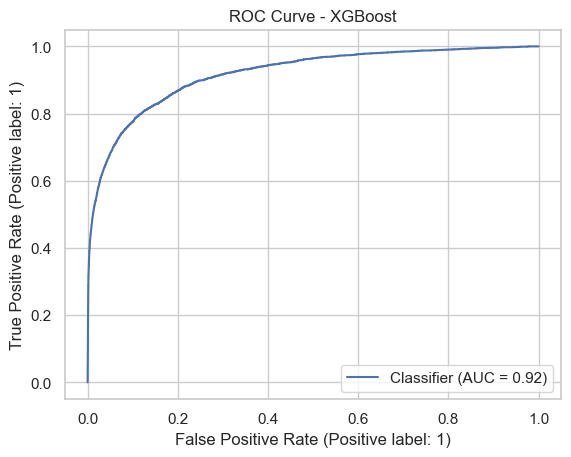

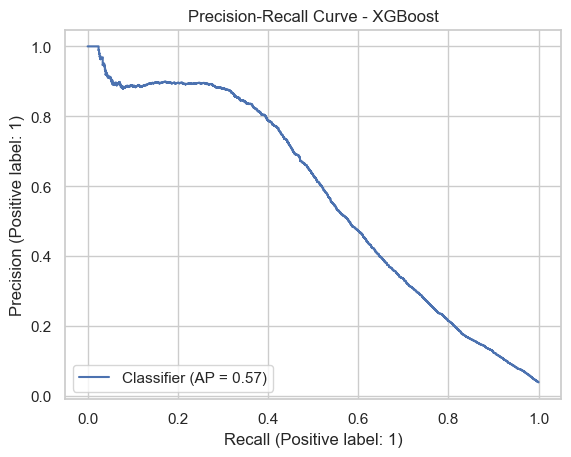

In [7]:
# ---Class imbalance ratio----------------------------------------------------
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 4))

# ---Define model-------------------------------------------------------------
xgb_classifier = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
)

# ---Full modeling pipeline---------------------------------------------------
xgb_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", xgb_classifier),
    ]
)

# ---Train model--------------------------------------------------------------
xgb_model.fit(X_train, y_train)
print("XGBoost training complete.")

# ---Validation metrics-------------------------------------------------------
xgb_results, xgb_pred_proba, xgb_pred = evaluate_model(
    model_name="XGBoost",
    fitted_model=xgb_model,
    X_valid=X_valid,
    y_valid=y_valid,
)

xgb_results

# ---Confusion matrix---------------------------------------------------------
xgb_cm = confusion_matrix(y_valid, xgb_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm)
disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()


# ---ROC curve----------------------------------------------------------------
RocCurveDisplay.from_predictions(y_valid, xgb_pred_proba)

plt.title("ROC Curve - XGBoost")
plt.show()


# ---Precision-Recall curve---------------------------------------------------
PrecisionRecallDisplay.from_predictions(y_valid, xgb_pred_proba)

plt.title("Precision-Recall Curve - XGBoost")
plt.show()

# LightGBM Model

LightGBM training complete.


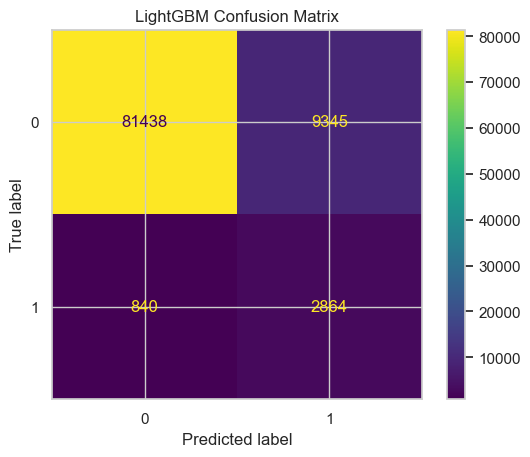

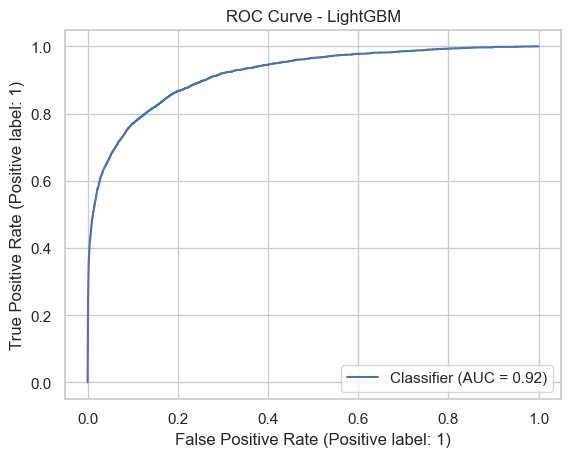

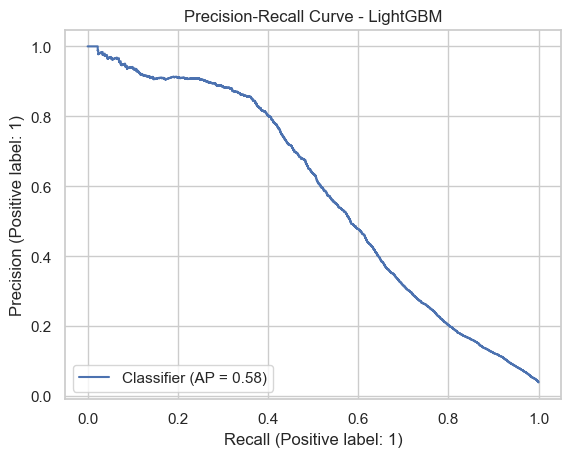

In [11]:
from lightgbm import LGBMClassifier

# ---Define model-------------------------------------------------------------
lgbm_classifier = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# ---Full modeling pipeline---------------------------------------------------
lgbm_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("classifier", lgbm_classifier),
    ]
)

# ---Train model--------------------------------------------------------------
lgbm_model.fit(X_train, y_train)

print("LightGBM training complete.")

# ---Validation metrics-------------------------------------------------------
lgbm_results, lgbm_pred_proba, lgbm_pred = evaluate_model(
    model_name="LightGBM",
    fitted_model=lgbm_model,
    X_valid=X_valid,
    y_valid=y_valid,
)

lgbm_results

# ---Confusion matrix---------------------------------------------------------
lgbm_cm = confusion_matrix(y_valid, lgbm_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=lgbm_cm)
disp.plot()

plt.title("LightGBM Confusion Matrix")
plt.show()

# ---ROC curve----------------------------------------------------------------
RocCurveDisplay.from_predictions(y_valid, lgbm_pred_proba)

plt.title("ROC Curve - LightGBM")
plt.show()

# ---Precision-Recall curve---------------------------------------------------
PrecisionRecallDisplay.from_predictions(y_valid, lgbm_pred_proba)

plt.title("Precision-Recall Curve - LightGBM")
plt.show()

# Model Comparison

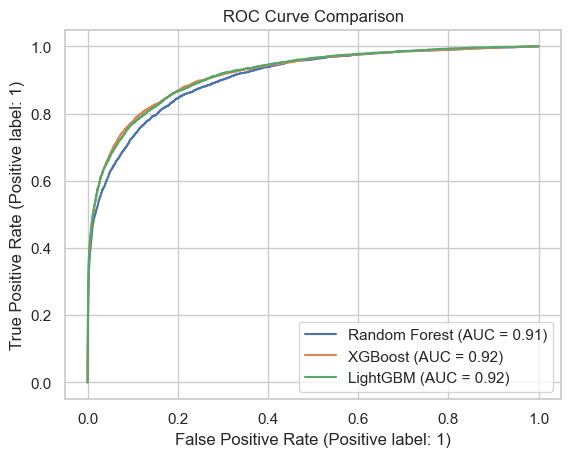

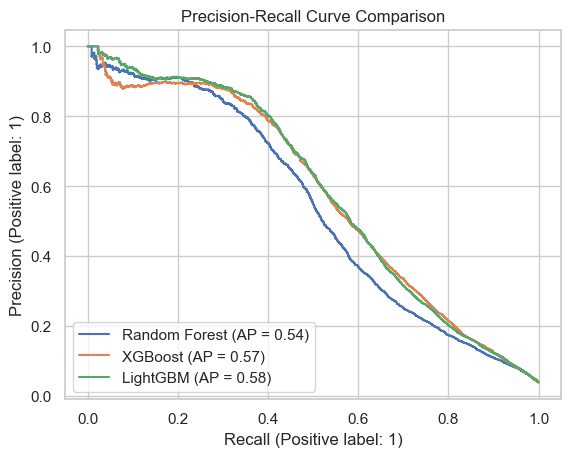

In [12]:
# ---Combine validation results-----------------------------------------------
comparison_results = pd.concat(
    [rf_results, xgb_results, lgbm_results],
    ignore_index=True,
).sort_values(by=["pr_auc", "roc_auc"], ascending=False)

comparison_results

# ---ROC comparison-----------------------------------------------------------
RocCurveDisplay.from_predictions(
    y_valid,
    rf_pred_proba,
    name="Random Forest",
)

RocCurveDisplay.from_predictions(
    y_valid,
    xgb_pred_proba,
    name="XGBoost",
    ax=plt.gca(),
)

RocCurveDisplay.from_predictions(
    y_valid,
    lgbm_pred_proba,
    name="LightGBM",
    ax=plt.gca(),
)

plt.title("ROC Curve Comparison")
plt.show()


# ---PR comparison------------------------------------------------------------
PrecisionRecallDisplay.from_predictions(
    y_valid,
    rf_pred_proba,
    name="Random Forest",
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    xgb_pred_proba,
    name="XGBoost",
    ax=plt.gca(),
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    lgbm_pred_proba,
    name="LightGBM",
    ax=plt.gca(),
)

plt.title("Precision-Recall Curve Comparison")
plt.show()

# Model Performance Summary

In [15]:
model_summary = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "ROC-AUC": [
        roc_auc_score(y_valid, rf_pred_proba),
        roc_auc_score(y_valid, xgb_pred_proba),
        roc_auc_score(y_valid, lgbm_pred_proba)
    ],
    "PR-AUC": [
        average_precision_score(y_valid, rf_pred_proba),
        average_precision_score(y_valid, xgb_pred_proba),
        average_precision_score(y_valid, lgbm_pred_proba)
    ]
})

model_summary = model_summary.sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)

model_summary

,Model,ROC-AUC,PR-AUC
0,LightGBM,0.9184,0.5812
1,XGBoost,0.9184,0.5739
2,Random Forest,0.9069,0.5374


# Tree Model Interpretation
Tree-based models improve performance relative to the logistic regression
baseline by capturing nonlinear relationships and feature interactions between
transaction attributes.

All three models demonstrate strong ranking ability, with ROC-AUC values around
0.91–0.92, representing a clear improvement over the linear baseline. This
indicates that fraud risk in the dataset is influenced by complex combinations
of features such as transaction amount patterns, device attributes, card
information, email domains, and temporal signals.

Comparing the models, Random Forest performs slightly worse than the boosting
models, particularly in the precision–recall curve. Gradient boosting methods
(XGBoost and LightGBM) achieve higher PR-AUC values, indicating better ability
to identify fraudulent transactions under severe class imbalance.

LightGBM achieves the highest PR-AUC among the evaluated models, suggesting
slightly stronger detection of fraud cases at comparable recall levels.
Boosting models generally outperform bagging methods like Random Forest
because they iteratively focus on difficult observations and capture complex
feature interactions more effectively.

Overall, tree-based models substantially improve fraud detection capability
compared to the linear baseline while maintaining strong ranking performance
across validation metrics.